# Microstrip Modes (2D Cross-Section)

This notebook builds a simple boxed microstrip cross-section (substrate + air + PEC strip conductor), solves eigenmodes with `WaveguideModeSolver`, and plots the first fields.

In [29]:
from palacetoolkit.mode_solver import WaveguideModeSolver

import importlib
import inspect

import gmsh
import matplotlib.pyplot as plt
import numpy as np
import palacetoolkit.utils as ptk_utils

importlib.reload(ptk_utils)
view_fe_mesh_2d = ptk_utils.view_fe_mesh_2d
view_fields_2d = ptk_utils.view_fields_2d
write_and_finalize_gmsh = ptk_utils.write_and_finalize_gmsh

In [10]:
sig = inspect.signature(WaveguideModeSolver.__init__)
print("WaveguideModeSolver.__init__ signature:")
print(sig)
print("\nPEC conductor support via boundary attributes:", "pec_bdr" in sig.parameters)
print("The solver enforces PEC by essential DOF elimination on selected boundary attributes.")

WaveguideModeSolver.__init__ signature:
(self, mesh, order=1, mu_inv=1.0, eps=1.0, pec_bdr='all')

PEC conductor support via boundary attributes: True
The solver enforces PEC by essential DOF elimination on selected boundary attributes.


In [11]:
def make_microstrip_mesh(
    box_w=8.0,
    h_sub=1.0,
    h_air=3.0,
    strip_w=1.8,
    strip_t=0.06,
    lc_bulk=0.18,
    lc_strip=0.05,
    filename=None,
):
    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("microstrip_modes")

    sub = gmsh.model.occ.addRectangle(-box_w / 2, -h_sub, 0, box_w, h_sub)
    air = gmsh.model.occ.addRectangle(-box_w / 2, 0.0, 0, box_w, h_air)
    strip = gmsh.model.occ.addRectangle(-strip_w / 2, 0.0, 0, strip_w, strip_t)

    _, outmap = gmsh.model.occ.fragment([(2, sub), (2, air), (2, strip)], [])
    strip_parts = list(outmap[2])
    gmsh.model.occ.remove(strip_parts, recursive=True)
    gmsh.model.occ.synchronize()

    all_surfs = [t for _, t in gmsh.model.getEntities(2)]
    substrate_surfs = []
    air_surfs = []
    for tag in all_surfs:
        _, cy, _ = gmsh.model.occ.getCenterOfMass(2, tag)
        if cy < -1e-9:
            substrate_surfs.append(tag)
        else:
            air_surfs.append(tag)

    if not substrate_surfs or not air_surfs:
        gmsh.finalize()
        raise RuntimeError("Failed to classify substrate/air surfaces for microstrip mesh")

    gmsh.model.addPhysicalGroup(2, substrate_surfs, tag=1, name="substrate")
    gmsh.model.addPhysicalGroup(2, air_surfs, tag=2, name="air")

    bnd = gmsh.model.getBoundary([(2, t) for t in substrate_surfs + air_surfs], oriented=False, combined=False)
    edge_tags = sorted({abs(t) for _, t in bnd})

    strip_edges = []
    ground_edges = []
    open_edges = []

    for et in edge_tags:
        ex, ey, _ = gmsh.model.occ.getCenterOfMass(1, et)
        on_strip_x = abs(ex) <= strip_w / 2 + 1e-6
        on_strip_y = (-1e-6 <= ey <= strip_t + 1e-6)
        if on_strip_x and on_strip_y:
            strip_edges.append(et)
            continue

        # Ground plane is the lower boundary of the simulation box.
        if abs(ey + h_sub) <= 1e-6:
            ground_edges.append(et)
        else:
            open_edges.append(et)

    if ground_edges:
        gmsh.model.addPhysicalGroup(1, ground_edges, tag=1, name="ground_plane")
    if strip_edges:
        gmsh.model.addPhysicalGroup(1, strip_edges, tag=2, name="strip_conductor")
    if open_edges:
        gmsh.model.addPhysicalGroup(1, open_edges, tag=3, name="open_boundary")

    for _, ptag in gmsh.model.getEntities(0):
        x, y, _ = gmsh.model.getValue(0, ptag, [])
        near_strip = (abs(x) <= strip_w / 2 + 0.4 and -0.1 <= y <= strip_t + 0.5)
        gmsh.model.mesh.setSize([(0, ptag)], lc_strip if near_strip else lc_bulk)

    gmsh.model.mesh.generate(2)
    return write_and_finalize_gmsh(filename, prefix="wg_microstrip_")

In [12]:
eps_sub = 9.8
eps_air = 1.0
mu_r = 1.0

omega = 18.0
kn_air = omega * np.sqrt(mu_r * eps_air)
kn_sub = omega * np.sqrt(mu_r * eps_sub)
print(f"Reference phase window (air to substrate): {kn_air:.4f} < kn < {kn_sub:.4f}")

Reference phase window (air to substrate): 18.0000 < kn < 56.3489


In [13]:
mesh_file = make_microstrip_mesh(
    box_w=8.0, h_sub=1.0, h_air=3.0, strip_w=1.8, strip_t=0.06, lc_bulk=0.18, lc_strip=0.05
)

mu_inv = {1: 1.0 / mu_r, 2: 1.0 / mu_r}
eps = {1: eps_sub, 2: eps_air}

# WaveguideModeSolver currently supports PEC marking via pec_bdr; it does not
# provide an absorbing boundary-condition model.
pec_bdr = [1, 2]  # ground plane + strip conductor

solver = WaveguideModeSolver(mesh_file, order=2, mu_inv=mu_inv, eps=eps, pec_bdr=pec_bdr)
results = solver.solve(omega, num_modes=8, mode_idx=1)

print("Computed microstrip modes:")
for i, kn in enumerate(results["kn"], start=1):
    if kn_air < kn.real < kn_sub and abs(kn.imag) < 0.1 * abs(kn.real):
        mode_type = "bound/hybrid"
    elif abs(kn.imag) > 0.1 * abs(kn.real):
        mode_type = "evanescent"
    else:
        mode_type = "radiative or box mode"
    print(f"  Mode {i:2d}: kn={kn.real:+10.6f}{kn.imag:+10.6f}j  [{mode_type}]")

  FE spaces: ND dofs = 27152, H1 dofs = 10988, total = 38140
  Essential DOFs: ND = 242, H1 = 243, total = 485
  Solving eigenvalue problem (omega = 18, sigma = -3492.72, size = 38140)...
  Found 8 modes:
    Mode 1: kn = +5.63384559e+01 -0.00000000e+00j <-- selected
    Mode 2: kn = +5.63261060e+01 -0.00000000e+00j
    Mode 3: kn = +5.63247853e+01 -0.00000000e+00j
    Mode 4: kn = +5.63172001e+01 -0.00000000e+00j
    Mode 5: kn = +5.63089125e+01 -0.00000000e+00j
    Mode 6: kn = +5.62972038e+01 -0.00000000e+00j
    Mode 7: kn = +5.62816967e+01 -0.00000000e+00j
    Mode 8: kn = +5.62655780e+01 -0.00000000e+00j
Computed microstrip modes:
  Mode  1: kn=+56.338456 -0.000000j  [bound/hybrid]
  Mode  2: kn=+56.326106 -0.000000j  [bound/hybrid]
  Mode  3: kn=+56.324785 -0.000000j  [bound/hybrid]
  Mode  4: kn=+56.317200 -0.000000j  [bound/hybrid]
  Mode  5: kn=+56.308912 -0.000000j  [bound/hybrid]
  Mode  6: kn=+56.297204 -0.000000j  [bound/hybrid]
  Mode  7: kn=+56.281697 -0.000000j  [bound

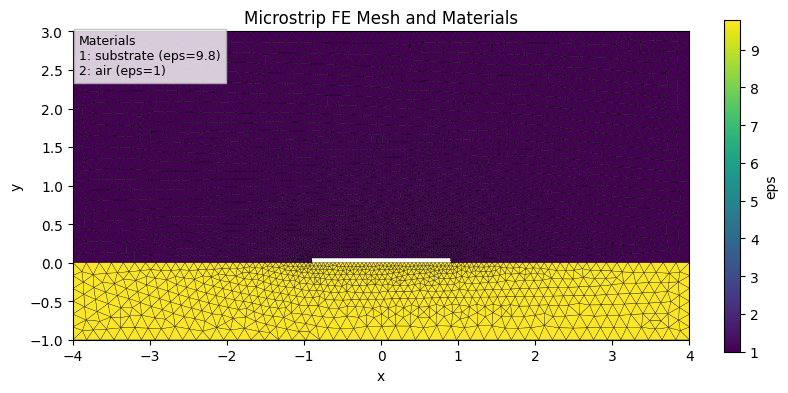

In [14]:
view_fe_mesh_2d(
    mesh_file=mesh_file,
    eps=eps,
    title="Microstrip FE Mesh and Materials",
    show_edges=True,
)




MFEM Warning: 18 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515



MFEM Warning: 18 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515



MFEM Warning: 18 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515



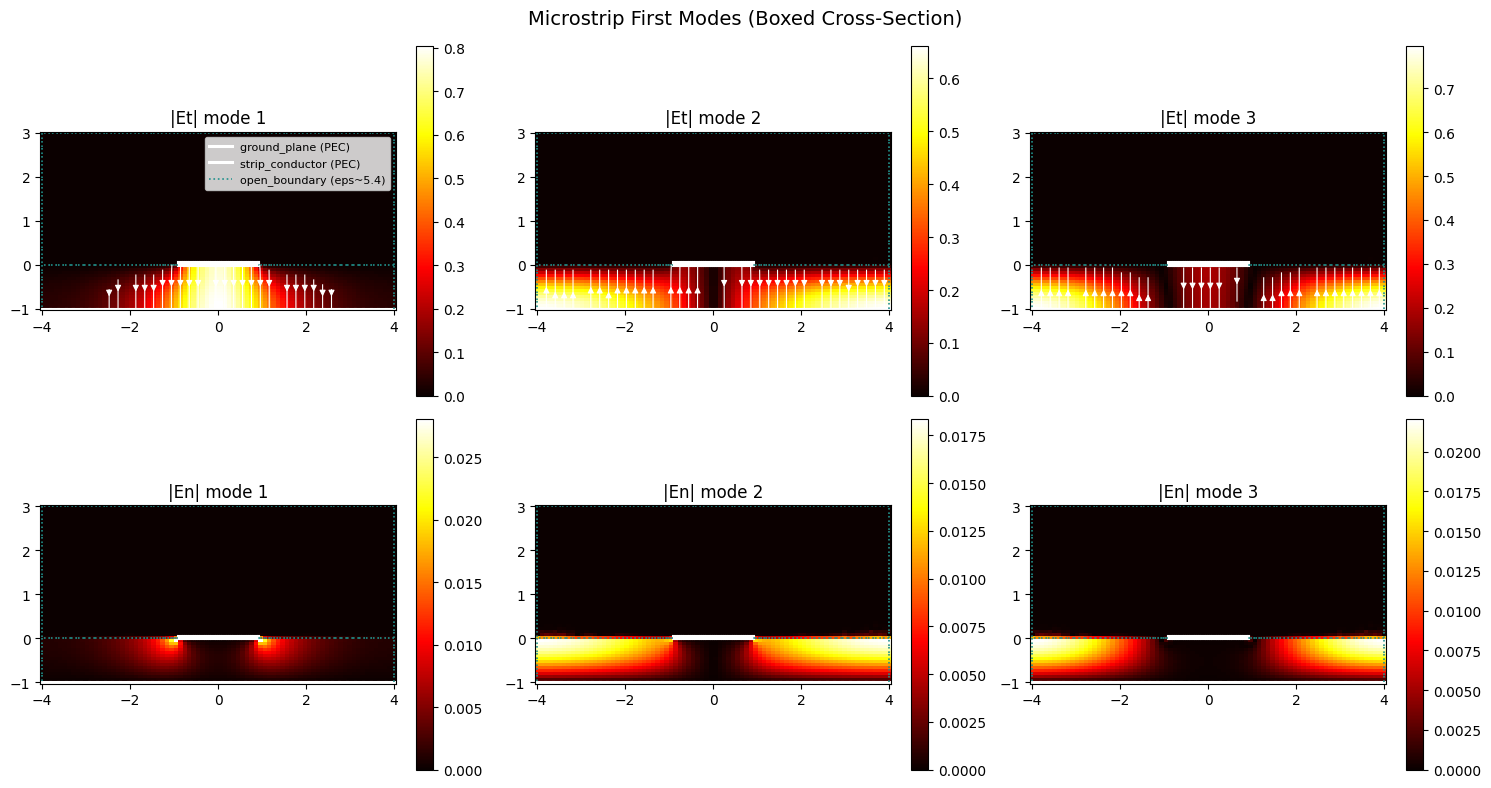

In [30]:
view_fields_2d(
    solver=solver,
    results=results,
    mesh_file=mesh_file,
    eps=eps,
    pec_bdr=pec_bdr,
    include_streamplot=True,
    streamplot_density=1.2,
    streamplot_show_arrows=True,
    streamplot_normalize=True,
    streamplot_seed_from_field=True,
    streamplot_seed_frac=0.1,
    streamplot_seed_stride=2,
    streamplot_mask_weak=True,
    streamplot_min_frac=0.1,
    num_modes=3,
    nx=80,
    ny=60,
    cmap="hot",
    title="Microstrip First Modes (Boxed Cross-Section)",
)